<a href="https://colab.research.google.com/github/leonardobrembilla/mio_progetto_titanic/blob/main/LeonardoBrembillaMLI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Progetto Start2Impact di Leonardo Brembilla**

# **🚢 Machine Learning: Predizione della Sopravvivenza sul Titanic**

---
**📘  Introduzione**

Il presente progetto ha l'obiettivo di applicare le competenze fondamentali di **Machine Learning** per sviluppare un **modello predittivo** basato sul celebre **dataset del Titanic (titanic_sub.csv**). Attraverso l'analisi di caratteristiche socio-demografiche e di viaggio dei passeggeri (come l'età, il sesso e la classe di viaggio), l'obiettivo finale è prevedere se un determinato passeggero sia **sopravvissuto o meno** al tragico naufragio.

---
**🎯 Obiettivi e Metodologia**

Per garantire la massima robustezza scientifica e rispettare i vincoli del progetto, il flusso di lavoro è strutturato nelle seguenti fasi:
1. **Caricamento e Pre-processing**:
- **Importazione del dataset tramite Pandas**
- **Gestione dell'indicizzazione e separazione del target (Survived) dalle feature complessive**
- **Codifica numerica delle variabili categoriali (Sex ed Embarked)** per renderle idonee agli algoritmi di Scikit-Learn
2. **Suddivisione Rigorosa dei Dati**:
- **Divisione iniziale del dataset in Train set (75%) e Test set definitivo (25%)**.
- Successiva e ulteriore **segmentazione del solo Train set per isolare una quota di Validation set (pari al 25% del sotto-insieme di addestramento)**.

La riproducibilità totale degli split e dei modelli è garantita dal bloccaggio del seed tramite **random_state=0**.

3. **Tuning degli Iperparametri e Diagnosi dell'Overfitting**: Addestramento di un **albero di decisione (DecisionTreeClassifier)** testando una lista di profondità massime specifiche (max_depth: 2, 5, 10, 25, None). Questa fase ha permesso di **analizzare l'andamento delle curve di accuratezza su Train e Validation per individuare** matematicamente e visivamente il **punto di ottimo, neutralizzando il rischio di overfitting**.

4. **Addestramento del Modello Finale (Retraining)**: Una volta **estratta la miglior profondità (max_depth=5)**, si è proceduto a **unire nuovamente i set di Train e Validation in un unico dataset completo (X_train_full)**, riaddestrando l'albero finale per sfruttare il **100% della conoscenza storica disponibile**.

5. **Valutazione e Ispezione Grafica**: **Test del modello definitivo sul Test set** (rimasto completamente integro e separato fino a questa fase) **per misurarne la reale capacità di generalizzazione tramite l'Accuratezza, la Matrice di Confusione e il Classification Report (Precision, Recall, F1-Score)**. Infine, **visualizzazione geometrica dei rami decisionali dell'albero ottenuto**.

---
🔬 **Robustezza del Workflow**

Per garantire una **corretta generalizzazione** del modello ed **evitare fenomeni di data leakage**, il preprocessing delle variabili è stato implementato mediante una **Pipeline di Scikit-Learn** e un **ColumnTransformer**. In questo modo le statistiche necessarie per l'imputazione dei valori mancanti e la codifica delle variabili categoriche vengono **apprese esclusivamente sul training set** e successivamente applicate ai dati di validation e test.

Inoltre, per contestualizzare le prestazioni del Decision Tree Classifier, è stato addestrato anche un modello di **Logistic Regression utilizzato come baseline**. Il **confronto tra i due modelli** ha consentito di verificare se la maggiore complessità dell'albero decisionale producesse un reale miglioramento delle prestazioni.

L'intero progetto è stato sviluppato seguendo le principali **best practice del Machine Learning**, includendo **analisi esplorativa dei dati**, **preprocessing**, **tuning degli iperparametri**, valutazione mediante metriche di classificazione e **interpretazione dei risultati**.



Prima di tutto bisogna importare una serie di **librerie core**

In [ ]:
# Manipolazione e analisi di dati strutturati tramite DataFrame
import pandas as pd

# Divide i dati in set di addestramento (train) e test
from sklearn.model_selection import train_test_split

# OneHotEncoder converte le variabili categoriali testuali in colonne binarie (0 o 1)
from sklearn.preprocessing import OneHotEncoder

# L'algoritmo di classificazione basato su albero di decisione
from sklearn.tree import DecisionTreeClassifier

# Calcola la percentuale di previsioni corrette del modello
from sklearn.metrics import accuracy_score

# Contiene le funzioni grafiche per esportare e disegnare l'albero di decisione
from sklearn import tree

# Creazione di grafici, diagrammi e visualizzazioni dell'albero
import matplotlib.pyplot as plt

# Importazione delle funzioni per calcolare le metriche di valutazione dettagliate
from sklearn.metrics import classification_report

# # confusion_matrix calcola la matrice per valutare l'accuratezza dei risultati di una classificazione.
# ConfusionMatrixDisplay permette di visualizzare graficamente la matrice di confusione calcolata
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Importazione della libreria Seaborn per creare grafici statistici avanzati e mappe di calore ad alto impatto visivo
import seaborn as sns

# Pipeline serve a incatenare più passaggi di trasformazione e stima in un unico blocco
from sklearn.pipeline import Pipeline

# ColumnTransformer permette di applicare trasformazioni diverse a colonne diverse del dataset
from sklearn.compose import ColumnTransformer

# SimpleImputer gestisce i dati mancanti (NaN) sostituendoli con valori scelti (es. media, mediana, moda)
from sklearn.impute import SimpleImputer

# LogisticRegression è l'algoritmo di classificazione lineare usato per prevedere classi discrete.
from sklearn.linear_model import LogisticRegression

**Caricamento del Dataset da GitHub (Metodo Consigliato)**

Questo metodo permette di **leggere direttamente il file online** senza doverlo caricare manualmente su Google Colab a ogni avvio della sessione. Il file viene ospitato in una **repository pubblica** su GitHub.

**Passaggi eseguiti:**
* Creazione di una **repository pubblica** su GitHub.
* Caricamento del file **titanic_sub.csv**.
* Recupero dell'indirizzo **URL Raw** del file.
* Importazione automatica del dataset in un **DataFrame di Pandas**.

In [ ]:
# Definisce la variabile 'url' contenente il link diretto (Raw) al file CSV su GitHub
url = "https://raw.githubusercontent.com/Leon56221/mio_progetto_titanic/refs/heads/main/titanic_sub.csv"

# Scarica il file dall'URL inserito e lo trasforma in un DataFrame chiamato 'df'
df = pd.read_csv(url, encoding='utf-8')

**In questa breve sezione andrai a visualizzare il dataset in forma tabellare**, così da averne una rappresentazione più intuitiva e comprendere meglio con che tipologia di dato hai a che fare. Per semplicità si mostrano solo le prime 10 occorrenze.

In [ ]:
# Visualizza le prime 10 righe del DataFrame per comprendere meglio con che tipologia di dato hai a che fare
df.head(10)

,PassengerId,Sex,Age,Pclass,Embarked,Survived
0,1,male,22.0,3,S,0
1,2,female,38.0,1,C,1
2,3,female,26.0,3,S,1
3,4,female,35.0,1,S,1
4,5,male,35.0,3,S,0
5,6,male,NaN,3,Q,0
6,7,male,54.0,1,S,0
7,8,male,2.0,3,S,0
8,9,female,27.0,3,S,1
9,10,female,14.0,2,C,1


Vai quindi a vedere più nel dettaglio quali sono i **metadati principali** delle colonne del dataset:

In [ ]:
# Mostra un riepilogo tecnico del DataFrame, inclusi i nomi delle colonne, il numero di valori non nulli, il tipo di dati
# (numerico, testo, ecc.) e la memoria utilizzata.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Sex          891 non-null    object 
 2   Age          714 non-null    float64
 3   Pclass       891 non-null    int64  
 4   Embarked     889 non-null    object 
 5   Survived     891 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


Vai ad identificare la presenza e la quantità di **dati mancanti** (valori nulli) all'interno di ogni colonna del tuo dataset.

In [ ]:
# Conta il numero totale di valori mancanti (NaN/Null) per ogni singola colonna del DataFrame
df.isnull().sum()

,0
PassengerId,0
Sex,0
Age,177
Pclass,0
Embarked,2
Survived,0


L'output mostra che ci sono:
- **177 valori mancanti** nella **colonna Age**(età)
- **2 valori mancanti** nella **colonna Embarked** (porto di imbarco).



**Analisi della Distribuzione dell'Età**

Questo grafico mostra come si distribuiscono le età all'interno del nostro dataset.

Attraverso l'istogramma possiamo visualizzare la **frequenza** di ogni fascia d'età, mentre le linee verticali ci permettono di confrontare immediatamente la **media** e la **mediana** del gruppo. Questo confronto è fondamentale per identificare la presenza di eventuali **asimmetrie** (skewness) nei dati.


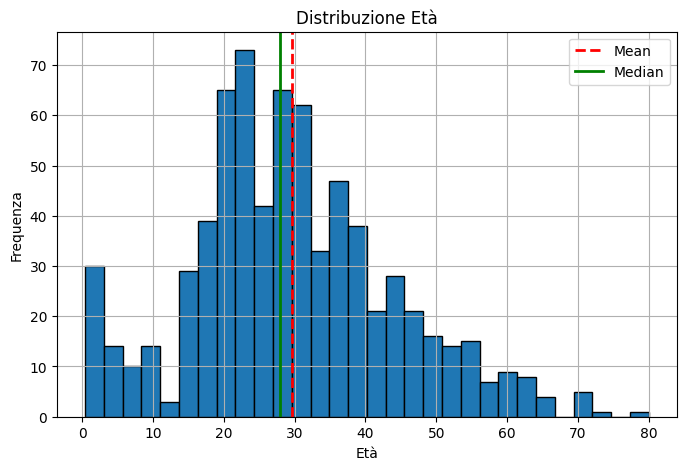

Media esatta dell'età:   29.70 anni
Mediana esatta dell'età: 28.00 anni


In [ ]:
# Inizializza la figura impostando larghezza (8) e altezza (5) in pollici
plt.figure(figsize=(8, 5))

# Disegna l'istogramma della colonna 'Age' dividendola in 30 intervalli (bins)
# I bordi delle barre sono colorati di nero per una migliore leggibilità
df['Age'].hist(
    bins=30,
    edgecolor='black'
)

# Traccia una linea verticale tratteggiata che indica il valore medio dell'età
plt.axvline(
    df['Age'].mean(),
    color='red',       # Consiglio: aggiungi un colore per distinguerla
    linestyle='--',    # Stile della linea: tratteggiato
    linewidth=2,       # Spessore della linea
    label='Mean'       # Etichetta per la legenda
)

# Traccia una linea verticale continua che indica il valore mediano dell'età
plt.axvline(
    df['Age'].median(),
    color='green',     # Consiglio: aggiungi un colore diverso per distinguerla
    linewidth=2,       # Spessore della linea
    label='Median'     # Etichetta per la legenda
)

# Imposta il titolo del grafico e le etichette per gli assi X e Y
plt.title('Distribuzione Età')
plt.xlabel('Età')
plt.ylabel('Frequenza')

# Mostra la legenda con i nomi delle linee (Mean e Median)
plt.legend()

# Visualizza il grafico finale pulito
plt.show()

# Calcola e stampa i valori esatti con due cifre decimali
print(f"Media esatta dell'età:   {df['Age'].mean():.2f} anni")
print(f"Mediana esatta dell'età: {df['Age'].median():.2f} anni")


**Analisi del Grafico di Distribuzione dell'Età**

- **Forma della Distribuzione**: Il grafico mostra una distribuzione **unimodale asimmetria a destra (positiva)**
- **Picco Principale**: La massima concentrazione di frequenza si trova nella fascia giovanile, precisamente tra i **20 e i 25 anni**, dove si superano le 70 osservazioni
- **Presenza di Neonati/Bambini**: Si nota un picco isolato e significativo nella fascia d'età **tra 0 e 5 anni** (circa 30 osservazioni), che indica una forte presenza di soggetti giovanissimi nel dataset rispetto alle fasce d'età immediatamente successive (5-15 anni)
- **Posizione della Mediana (Linea Verde)**: Si attesta intorno ai **28 anni**, dividendo esattamente a metà la popolazione del campione (il 50% dei soggetti ha meno di 28 anni e il 50% ne ha di più)
- **Posizione della Media (Linea Rossa Tratteggiata)**: Si posiziona leggermente più a destra, a **29.70 anni**
- **Interpretazione dell'Asimmetria**: Il fatto che la **Media sia maggiore della Mediana (Media > Mediana)** conferma matematicamente l'**asimmetria a destra** (destrorsa). Questo fenomeno è causato dalla presenza di individui in età avanzata (fino a 80 anni) che "trascinano" il valore della media verso l'alto, mentre la mediana rimane più stabile e vicina al picco principale.

**Analisi della Sopravvivenza in base al Sesso**

Questo grafico analizza la **relazione tra il sesso dei passeggeri e la loro percentuale di sopravvivenza**.

Attraverso una tabella a doppia entrata (crosstab) **normalizzata per indice**, trasformiamo le frequenze assolute in percentuali (da 0 a 1). Il grafico a barre **impilate (stacked)** permette di confrontare visivamente e immediatamente l'impatto del genere sulla probabilità di sopravvivenza, evidenziando se le proporzioni di sopravvissuti variano significativamente tra uomini e donne.


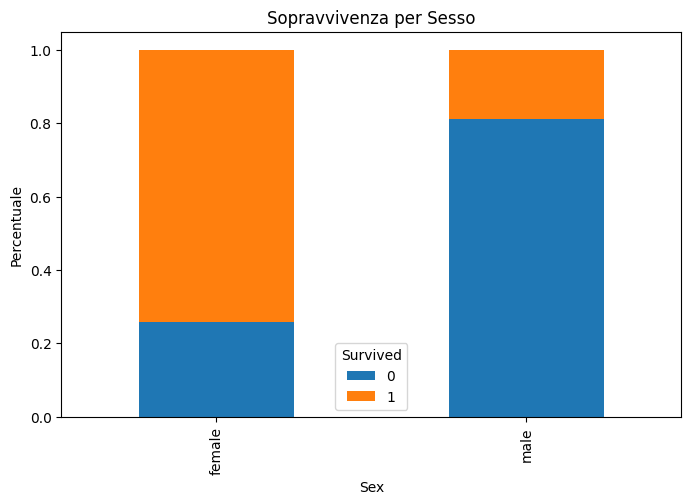

In [ ]:
# Crea una tabella di contingenza (cross-tabulation) tra Sesso e Sopravvivenza.
# normalize='index' calcola le percentuali riga per riga (somma maschi = 100%, somma femmine = 100%).
survival_by_sex = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
)

# Disegna un grafico a barre (kind='bar')
# stacked=True impila le barre verticalmente per mostrare la composizione percentuale (0% - 100%)
# figsize=(8,5) imposta le dimensioni della figura
survival_by_sex.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Imposta il titolo principale del grafico
plt.title('Sopravvivenza per Sesso')

# Imposta l'etichetta dell'asse verticale Y
plt.ylabel('Percentuale')

# Mostra il grafico finale a schermo
plt.show()

**Analisi della Sopravvivenza per Sesso**

- **Disparità Netta di Genere**: Il grafico evidenzia una **fortissima associazione** tra il sesso dei passeggeri e la probabilità di sopravvivenza, confermando storicamente la politica del "prima le donne e i bambini"
- **Soggetti Femminili (female)**: Le donne registrano un tasso di sopravvivenza straordinariamente alto. Circa il **74% delle donne è sopravvissuto (barra arancione 1)**, a fronte di un **tasso di mortalità molto contenuto, pari a circa il 26% (barra blu 0)**
- **Soggetti Maschili (male)**: La situazione per gli uomini è diametralmente opposta. Oltre l'**80% degli uomini non è sopravvissuto (barra blu 0)**, mentre solo una piccola minoranza, pari a **circa il 19-20%, è riuscita a salvarsi (barra arancione 1**)
- **Conclusione Statistica**: Il genere rappresenta una delle **variabili predittive più influenti** dell'intero dataset. La probabilità di sopravvivere per una donna è stata di quasi **quattro volte superiore** rispetto a quella di un uomo.

**Analisi della Sopravvivenza in base alla Classe di Viaggio**

Questo grafico esamina l'**impatto della classe socio-economica dei passeggeri sulla loro percentuale di sopravvivenza**.

Attraverso una tabella a doppia entrata (crosstab) **normalizzata per riga**, analizziamo le tre classi di viaggio (`Pclass`: 1ª, 2ª e 3ª classe). Il grafico a barre **impilate (stacked)** evidenzia visivamente se il possesso di un biglietto di una classe superiore abbia garantito o meno un **accesso prioritario alle scialuppe di salvataggio**, evidenziando le disparità tra i diversi ponti della nave.


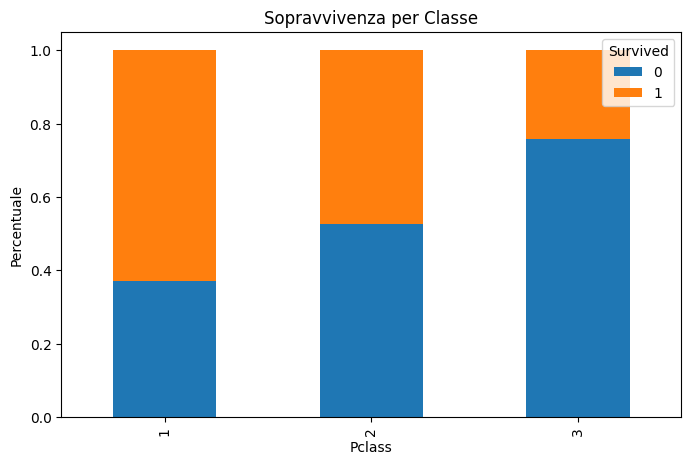

In [ ]:
# Crea una tabella di contingenza tra Classe di viaggio (Pclass) e Sopravvivenza.
# normalize='index' calcola le percentuali per ciascuna classe (la somma di ogni classe è 100%).
survival_by_class = pd.crosstab(
    df['Pclass'],
    df['Survived'],
    normalize='index'
)

# Disegna il grafico a barre (kind='bar')
# stacked=True impila le barre verticalmente per mostrare le proporzioni (0% - 100%)
# figsize=(8,5) imposta le dimensioni ottimali della figura
survival_by_class.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Imposta il titolo del grafico
plt.title('Sopravvivenza per Classe')

# Imposta l'etichetta dell'asse verticale Y
plt.ylabel('Percentuale')

# Visualizza il grafico finale a schermo
plt.show()

**Analisi della Sopravvivenza per Classe di Viaggio**

- **Forte Influenza della Classe**: Il grafico dimostra in modo inequivocabile che lo **status socio-economico** (la classe del biglietto) ha pesato enormemente sulla probabilità di salvarsi. Il tasso di sopravvivenza cala drasticamente passando dalla prima alla terza classe
- **Prima Classe (1)**: Ha registrato la percentuale di salvezza più alta. Circa il **63% dei passeggeri è sopravvissuto (barra arancione 1)**, mentre solo il **37% circa è deceduto (barra blu 0)**. È l'unica classe in cui i sopravvissuti superano i deceduti
- **Seconda Classe (2)**: La situazione è quasi in perfetto equilibrio, ma con una leggera prevalenza di vittime. Circa il **47% dei passeggeri è sopravvissuto**, a fronte di un **53% di decessi**
- **Terza Classe (3)**: Ha subito l'impatto più drammatico e tragico. Oltre il **75% dei passeggeri non è sopravvissuto (barra blu 0)**, mentre solo una piccola minoranza, pari a circa il **24-25%, è riuscita a salvarsi (barra arancione 1)**
- **Conclusione Statistica**: Esiste una **correlazione lineare inversa** tra il numero della classe e la sopravvivenza: all'aumentare della classe (da 1 a 3), la probabilità di sopravvivere diminuisce drasticamente. I passeggeri di prima classe hanno avuto una probabilità di salvarsi **quasi 3 volte superiore** rispetto a quelli di terza classe, consolidando la **variabile Pclass come una feature fondamentale per il modello predittivo**.

La **colonna** migliore da usare come **indice** è:
- **PassengerId**

Perché:

- **Identifica univocamente ogni passeggero**
- **Non è utile** alla previsione
- **Evita duplicati**


In [ ]:
# Controlla se 'PassengerId' è già l'indice o se è ancora una colonna normale da trasformare
if df.index.name == 'PassengerId':
    print("\nIl dataset è già correttamente indicizzato su 'PassengerId'.")
elif 'PassengerId' in df.columns:
    df.set_index('PassengerId', inplace=True)
    print("\nDataset indicizzato correttamente su 'PassengerId'.")
else:
    print("\nAttenzione: 'PassengerId' non è stato trovato né come colonna né come indice.")



Dataset indicizzato correttamente su 'PassengerId'.


Si procede con la **separazione tra Feature e Target**.

**Target** richiesto è:
- **Survived**

quindi si crea:

- **X → feature**
- **y → target**

In [ ]:
# Crea la matrice X escludendo la colonna 'Survived' (axis=1 indica che stiamo rimuovendo una colonna)
X = df.drop(
    "Survived", axis=1
)  # Rimuove la colonna del target per tenere solo le caratteristiche

# Crea il vettore y contenente la variabile obiettivo che il modello deve prevedere
y = df[
    "Survived"
]  # Isola la colonna target con le risposte corrette (sopravvissuto o meno)

Per vedere se tutto è stato **separato correttamente** e controllare l'aspetto finale dei dati.

In [ ]:
# Stampa a schermo il numero totale di righe e di colonne presenti nella matrice delle caratteristiche X
print(f"Dimensioni della matrice X (Righe, Colonne): {X.shape}")

# Stampa un testo di intestazione per identificare la visualizzazione successiva
print("\nPrime 5 righe delle caratteristiche (X):")

# Mostra in modo formattato e grafico la tabella contenente le prime 5 righe della matrice X
display(X.head())

# Stampa a schermo il numero totale di elementi (righe) presenti nel vettore obiettivo y
print(f"\nDimensioni del vettore y (Righe,): {y.shape}")

# Stampa un testo di intestazione per identificare la visualizzazione del target
print("\nPrime 5 righe della variabile obiettivo (y):")

# Mostra in modo formattato le prime 5 risposte (sopravvissuto o meno) del vettore y
display(y.head())

Dimensioni della matrice X (Righe, Colonne): (891, 4)

Prime 5 righe delle caratteristiche (X):


,Sex,Age,Pclass,Embarked
PassengerId,,,,
1,male,22.0,3,S
2,female,38.0,1,C
3,female,26.0,3,S
4,female,35.0,1,S
5,male,35.0,3,S



Dimensioni del vettore y (Righe,): (891,)

Prime 5 righe della variabile obiettivo (y):


,Survived
PassengerId,
1,0
2,1
3,1
4,1
5,0


Controlla i **tipi di dati**:

In [ ]:
# Verifico i tipi di dati per trovare errori
X.dtypes    # Output atteso: controllare se ci sono stringhe dove dovrebbero esserci numeri

,0
Sex,object
Age,float64
Pclass,int64
Embarked,object


Si va a fare il **Train/Test Split** perchè prima di procedere con l'addestramento del modello, è fondamentale separare i dati storici in due insiemi indipendenti: il **Train Set e il Test Set**.

Questa operazione viene eseguita applicando una **stratificazione sul target**, una tecnica indispensabile per mantenere inalterata la proporzione tra passeggeri sopravvissuti e non sopravvissuti in entrambi i sotto-insiemi. In questo modo si evita di introdurre distorsioni statistiche. Inoltre, il bloccaggio del seme casuale tramite il **parametro random_state=0 assicura la totale riproducibilità** dell'esperimento a ogni esecuzione.

Il codice seguente isola il **25% del dataset originale per il Test Set definitivo**(che rimarrà protetto e inutilizzato fino alla valutazione finale), **destinando il restante 75% all'addestramento e alla successiva validazione**.

In [ ]:
# Assegna i quattro output della scissione: feature e target per train e test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,      # Matrice delle variabili predittive (feature) di input
    y,      # Vettore della variabile target da predire
    test_size=0.25,   # Destina il 25% dei dati al test set (il 75% rimanente va al train set)
    random_state=0,   # Blocca il seme casuale per garantire la riproducibilità dei risultati
    stratify=y      # Mantiene la stessa proporzione di classi (es. sopravvissuti/non) in train e test
)

# Stampa i risultati
print(f"Train Full Set (75%): {X_train_full.shape} | Test Set definitivo (25%): {X_test.shape}")

Train Full Set (75%): (668, 4) | Test Set definitivo (25%): (223, 4)


Commento tecnico:
- **Proporzione 75/25 Rispettata**: Il dataset originale conteneva in totale **891 passeggeri** (righe). La suddivisione ha assegnato correttamente il **75% dei record al Train Full Set (668 righe) e il restante 25% al Test Set definitivo (223 righe)**, rispettando perfettamente il bilanciamento dei campioni (668 + 223 = 891)
- **Integrità delle Feature**: Il **numero 4** all'interno delle tuple indica le colonne predittive (le caratteristiche dei passeggeri selezionate per l'addestramento, escluse il target Survived e l'identificativo PassengerId). Il fatto che entrambi i sotto-insiemi presentino esattamente lo stesso numero di colonne dimostra la coerenza geometrica del processo di split
- **Isolamento del Test Set**: Con questo split abbiamo "congelato" 223 passeggeri. Questi dati rimarranno totalmente inediti per l'algoritmo durante l'intera fase di addestramento e ottimizzazione, garantendo una valutazione finale oggettiva e neutralizzando alla radice il rischio di Data Leakage.

Creazione del **Validation Set per il Tuning degli Iperparametri**

Per poter **testare diverse configurazioni** del modello (come la **profondità massima dell'albero**) **senza contaminare il Test Set definitivo**, è **necessario effettuare una seconda suddivisione**.

Il **Train Full Set (pari al 75% dei dati iniziali)** viene ulteriormente segmentato per isolare una quota di **Validation Set pari al 25% del sotto-insieme di addestramento**. Anche in questa fase si applica la **stratificazione e si mantiene il medesimo seed casuale (random_state=0) per garantire un partizionamento coerente e stabile**. Questo **ambiente a tre vie (Train, Validation, Test) permette di diagnosticare con precisione la presenza di eventuale overfitting** durante la ricerca dei parametri ottimali.

In [ ]:
# Crea i set di addestramento e validazione dividendo ulteriormente il set 'full'
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,    # Matrice delle feature di partenza (75% del dataset originale)
    y_train_full,    # Vettore dei target di partenza corrispondenti
    test_size=0.25,  # Destina il 25% del train_full alla validazione (circa 18.75% del totale iniziale)
    random_state=0,  # Fissa il seme casuale per rendere la divisione identica a ogni esecuzione
    stratify=y_train_full   # Preserva la distribuzione originale delle classi anche nel validation set
)

# Stampa i risultati
print(f"Train Set: {X_train.shape} | Validation Set: {X_val.shape} | Test Set: {X_test.shape}")


Train Set: (501, 4) | Validation Set: (167, 4) | Test Set: (223, 4)


**Commento tecnico**:
- **Proporzione Rispettata**: **Applicando nuovamente la proporzione 75/25 sul blocco di addestramento iniziale** (Train Full di 668 righe), i calcoli matematici tornano con precisione: il **75% corrisponde a 501 righe (destinate al Train Set definitivo) e il 25% corrisponde a 167 righe (destinate al Validation Set)**, con un bilanciamento perfetto (501 + 167 = 668)
- **Nessuna Dispersione di Variabili**: Il numero di colonne è rimasto costantemente ancorato a **4** in tutti e tre i sottoinsiemi, confermando la perfetta coerenza geometrica delle matrici durante la segmentazione.
- **Separazione dei Ruoli Sperimentali**: La struttura finale a tre blocchi riflette la massima best practice del Machine Learning:
1. **Train Set (501 righe)** verrà usato esclusivamente per far apprendere le regole all'albero di decisione.
2. **Validation Set (167 righe)** servirà come terreno di prova neutro per testare e confrontare le diverse profondità massime (max_depth), consentendo di scegliere la migliore ed evitare l'overfitting.
3. **Test Set (223 righe)** rimane blindato e sigillato fino alla fine per la misurazione delle prestazioni reali e della capacità di generalizzazione dell'algoritmo.

**Definizione e Separazione delle Variabili (Feature Selection)**

In questa fase andiamo a mappare e classificare le colonne del nostro dataset in due macro-categorie principali: **variabili numeriche** e **variabili categoriali**.

Questa separazione è un passaggio fondamentale nel processo di **Data Preprocessing**. Ci permette infatti di applicare in modo automatizzato le corrette tecniche di analisi successiva, come l'imputazione dei valori mancanti, la standardizzazione dei numeri o la conversione in stringhe numeriche (One-Hot Encoding) per i modelli di Machine Learning.

In [ ]:
# Elenco delle variabili numeriche (caratteristiche quantitative)
# 'Age' è una variabile continua, 'Pclass' è una variabile ordinale
numeric_features = ['Age', 'Pclass']

# Elenco delle variabili categoriali (caratteristiche qualitative o nominali)
# 'Sex' (genere) e 'Embarked' (porto di imbarco) contengono stringhe/categorie testuali
categorical_features = ['Sex', 'Embarked']


**Preprocessing delle Variabili Numeriche con le Pipeline**

In questa cella definiamo una **Pipeline di trasformazione** dedicata esclusivamente alle caratteristiche numeriche del dataset.

Le **Pipeline di scikit-learn** sono uno strumento fondamentale per standardizzare il flusso di lavoro (workflow) e prevenire il fenomeno del **data leakage** durante la validazione del modello. All'interno di questa pipeline, utilizziamo l'oggetto **SimpleImputer** per gestire in modo automatizzato i **valori mancanti (NaN)**, sostituendoli in questo caso con la **mediana** della rispettiva colonna. La mediana è una scelta robusta poiché non viene influenzata da eventuali valori anomali (outlier) presenti nei dati.

In [ ]:
# Definisce la pipeline per il trattamento dei dati numerici
numeric_transformer = Pipeline(
    steps=[
        # Primo e unico passaggio (step): imputazione dei valori mancanti.
        # 'imputer' è il nome arbitrario assegnato a questo specifico passaggio.
        # SimpleImputer(strategy='median') sostituisce ogni valore NaN con la mediana della colonna.
        ('imputer',
         SimpleImputer(strategy='median'))
    ]
)

**Preprocessing delle Variabili Categoriali con le Pipeline**

In questa cella definiamo una **Pipeline di trasformazione** specifica per le caratteristiche qualitative del dataset.

Questo processo si articola in due passaggi sequenziali fondamentali:
1. **Imputazione dei dati mancanti**: Utilizziamo **SimpleImputer** con strategia **most_frequent** per sostituire eventuali valori nulli con la **moda** (il valore che si ripete più spesso nella colonna).
2. **Codifica delle categorie**: Poiché i modelli di Machine Learning non possono elaborare direttamente testi o stringhe, utilizziamo **OneHotEncoder** per convertire le variabili categoriali in **variabili dummy numeriche** (composte da 0 e 1). L'argomento **handle_unknown='ignore'** è una precauzione di sicurezza fondamentale: evita che il codice vada in errore se nel set di test dovessero comparire categorie nuove o mai viste durante la fase di addestramento (training).


In [ ]:
# Definisce la pipeline per il trattamento dei dati categoriali
categorical_transformer = Pipeline(
    steps=[
        # Primo step: riempimento dei valori mancanti (NaN) con la moda della colonna
        ('imputer',
         SimpleImputer(strategy='most_frequent')),

        # Secondo step: conversione delle stringhe in colonne numeriche binarie (0 o 1).
        # handle_unknown='ignore' ignora eventuali categorie sconosciute in fase di test
        ('onehot',
         OneHotEncoder(handle_unknown='ignore'))
    ]
)

**Integrazione dei Trasformatori con ColumnTransformer**

In questa cella uniamo le pipeline create in precedenza all'interno di un unico oggetto chiamato **ColumnTransformer**.

Questo strumento di **scikit-learn** permette di applicare flussi di preprocessing **differenziati e mirati** a colonne specifiche del dataset in un solo colpo. In questo modo, la pipeline **numeric_transformer** agirà esclusivamente sulle colonne definite in **numeric_features** (i dati numerici), mentre la **categorical_transformer** elaborerà solo le colonne presenti in **categorical_features** (i dati categoriali). Il risultato sarà una matrice di dati pulita, codificata e **pronta per essere data in pasto al modello di Machine Learning**.


In [ ]:
# Crea l'oggetto globale per il preprocessing dei dati
preprocessor = ColumnTransformer(
    transformers=[
        # Primo blocco: applica la pipeline dei numeri alle colonne numeriche
        (
            'num',                  # Nome identificativo del blocco
            numeric_transformer,    # La pipeline numerica definita prima
            numeric_features        # Lista delle colonne da elaborare (['Age', 'Pclass'])
        ),

        # Secondo blocco: applica la pipeline delle categorie alle colonne categoriali
        (
            'cat',                  # Nome identificativo del blocco
            categorical_transformer, # La pipeline categoriale definita prima
            categorical_features    # Lista delle colonne da elaborare (['Sex', 'Embarked'])
        )
    ]
)

**Definizione dello Spazio degli Iperparametri (max_depth)**

Per individuare la struttura ottimale del modello e prevenire i fenomeni di **underfitting e overfitting**, viene definita una lista di configurazioni per l'iperparametro **max_depth**. **Questo parametro controlla la profondità massima** dell'albero di decisione, ovvero il numero massimo di biforcazioni (nodi) che l'algoritmo può creare a partire dalla radice.

Testare valori differenti permette di analizzare la risposta del modello a diversi **livelli di complessità**: si passa da strutture molto semplici e interpretabili fino a configurazioni a crescita libera. Nello specifico, le **profondità richieste per il test** sono:

- **2** (Profondità iniziale / Albero semplice)
- **5** (Complessità intermedia)
- **10** (Struttura profonda)
- **25** (Struttura molto profonda)
- **None** (Nessun limite / Massima espansione)

Inizializza quindi la **lista delle configurazioni** che verrà ciclata dall'algoritmo per valutare le metriche di accuratezza:

In [ ]:
# Lista delle profondità massime da testare per l'albero di decisione
depths = [
    2,     # Albero molto semplice (rischio underfitting)
    5,     # Complessità intermedia (potenziale punto di ottimo)
    10,    # Albero profondo
    25,    # Albero molto profondo
    None   # Crescita libera: l'albero si espande fino alla massima purezza dei nodi
]

**Ottimizzazione della Profondità dell'Albero con Pipeline Integrata**

In questa cella eseguiamo un ciclo di ottimizzazione (tuning) per trovare la migliore **profondità massima (max_depth`)** del nostro albero di decisione.

La novità fondamentale è che ora il classificatore è inserito all'interno di una **Pipeline complessiva** che include il blocco di preprocessing (**preprocessor**). In questo modo, per ogni valore di profondità testato, i dati di training e validazione vengono **automaticamente puliti, trasformati e codificati** prima di essere elaborati dall'algoritmo. Questo previene qualsiasi errore manuale e garantisce una corretta valutazione dell'**accuratezza** sia sul set di addestramento che su quello di convalida, aiutandoci a identificare il punto ideale prima che inizi l'**overfitting**.


In [ ]:
# Inizializzazione dei dizionari per salvare separatamente i punteggi di train e validation
train_results = {}
val_results = {}

# Ciclo attraverso i diversi valori di profondità dell'albero definiti nella lista depths
for depth in depths:
    # Creazione della pipeline che unisce il preprocessing e il modello attuale
    model = Pipeline([
        (
            'preprocessor',
            preprocessor       # Il ColumnTransformer globale definito in precedenza
        ),
        (
            'classifier',
            DecisionTreeClassifier(
                max_depth=depth, # Profondità dinamica basata sul ciclo attuale
                random_state=0   # Garantisce la riproducibilità dei risultati
            )
        )
    ])

    # Addestramento della pipeline complessiva (esegue il fit_transform del preprocessor e il fit del classifier)
    model.fit(X_train, y_train)

    # Calcola l'accuratezza sul set di addestramento usando i dati grezzi X_train (la pipeline si occupa di trasformarli)
    acc_t = accuracy_score(y_train, model.predict(X_train))

    # Calcola l'accuratezza sul set di validazione usando i dati grezzi X_val
    acc_v = accuracy_score(y_val, model.predict(X_val))

    # Memorizzazione dei risultati nei rispettivi dizionari usando la profondità come chiave
    train_results[depth] = acc_t
    val_results[depth] = acc_v

    # Gestione formattata del testo della stringa per riconoscere il valore None come "Profondità Max"
    label = f"Profondità {depth}" if depth is not None else "Profondità Max"

    # Stampa a schermo il confronto delle prestazioni in percentuale per rilevare visivamente l'overfitting
    print(f"• {label} -> Treno (Train): {acc_t*100:.2f}% | Convalida (Val): {acc_v*100:.2f}%")

• Profondità 2 -> Treno (Train): 81.24% | Convalida (Val): 76.65%
• Profondità 5 -> Treno (Train): 85.83% | Convalida (Val): 79.04%
• Profondità 10 -> Treno (Train): 92.61% | Convalida (Val): 78.44%
• Profondità 25 -> Treno (Train): 93.61% | Convalida (Val): 79.04%
• Profondità Max -> Treno (Train): 93.61% | Convalida (Val): 79.04%


**Il modello mostra un comportamento classico di ottimizzazione degli iperparametri (tuning)**, descrivendo una perfetta curva a "U rovesciata" tipica del trade-off tra bias e varianza:
- **Underfitting (Profondità 2 - Convalida: 76.65%)**: Con solo due livelli, l'**albero è troppo semplice**. Non riesce a catturare la complessità e le relazioni presenti nei dati, portando a un'accuratezza inferiore  sia nel Train (**81.24%**) che nella Convalida.
- **Miglior Compromesso (Profondità 5 - Convalida: 79.04%)**: Questa rappresenta la profondità ottimale nel nostro ciclo. L'albero raggiunge un ottimo equilibrio: l'accuratezza del Train sale all'**85.83%** e la Convalida tocca il picco del **79.04%**, dimostrando la **massima capacità di generalizzazione** su dati nuovi.
- **Overfitting iniziale (Profondità 10 - Convalida: 78.44%)**: Aumentando la complessità, l'accuratezza del Train schizza al **92.61%**, ma quella di Convalida **scende al 78.44%**. Questo è il segnale classico dell'**overfitting**: l'albero sta diventando troppo specifico e inizia a memorizzare il rumore del Train Set, perdendo colpi sui dati di test.
- **Stabilizzazione (Profondità 25 e Max - Convalida: 79.04%)**: Il fatto che i risultati a profondità 25 e profondità massima siano identici (**93.61% in Train, 79.04% in Val**) indica che l'albero ha **smesso di crescere** spontaneamente attorno al livello 25. Questo accade perché le foglie sono già diventate purissime o non contengono abbastanza campioni per generare ulteriori scissioni (split).

Una volta conclusa la fase di addestramento iterativo, è necessario **estrarre matematicamente la configurazione che ha garantito le migliori prestazioni di generalizzazione**.

Il codice implementa una ricerca automatica all'interno del dizionario dei risultati per identificare la **profondità ottimale (best_depth)**. **Questo processo avviene isolando il valore massimo di accuratezza sul Validation Set, garantendo la scelta del miglior compromesso tra la semplicità del modello e la sua capacità predittiva**. Il parametro così individuato guiderà la successiva fase di addestramento finale, assicurando che la scelta non sia basata su una valutazione visiva approssimativa, ma su un **criterio oggettivo di massima resa statistica**.

In [ ]:
# Trova la chiave (profondità) associata al valore massimo (accuratezza) nel dizionario results
best_depth = max(val_results, key=val_results.get)
# Recupera il valore di accuratezza più alto memorizzato usando la migliore profondità trovata
best_accuracy = val_results[best_depth]

# Stampa l'intestazione del blocco riassuntivo finale
print("\n🏆 RISULTATO FINALE:")
# Mostra la profondità ottimale dell'albero (se è None, indica che l'albero non ha limiti di crescita)
print(f"Miglior parametro 'max_depth': {best_depth}")
# Mostra la percentuale di accuratezza massima sul set di validazione, formattata a due cifre decimali
print(f"Accuratezza raggiunta: {best_accuracy * 100:.2f}%")


🏆 RISULTATO FINALE:
Miglior parametro 'max_depth': 5
Accuratezza raggiunta: 79.04%


Questo risultato conferma esattamente l'analisi precedente:
- **la profondità 5 è il valore ottimale** per evitare l'overfitting e garantire la massima capacità di generalizzazione del tuo albero di decisione.

Per validare la scelta del parametro ottimale in modo empirico, i risultati numerici raccolti vengono tradotti in un **grafico diagnostico a due linee**. Questa visualizzazione permette di confrontare direttamente l'andamento delle due curve di accuratezza al variare della complessità del modello.

L'analisi visiva si concentra sulla separazione delle curve:
- **La curva di Training** (linea tratteggiata blu) descrive l'apprendimento storico. Se cresce verso il 100%, indica che l'albero sta memorizzando i dati specifici.
- **La curva di Validation** (linea continua verde) riflette la reale capacità di generalizzazione del modello.

**Il punto in cui la curva di validazione raggiunge il suo picco massimo e inizia a flettere verso il basso — mentre quella di training continua a salire — segna l'inizio dell'overfitting**. Il codice seguente genera questo grafico e inserisce un **indicatore visivo rosso sul punto di massimo compromesso (corrispondente a max_depth=5)**, isolando visivamente la struttura dell'albero più robusta ed equilibrata.

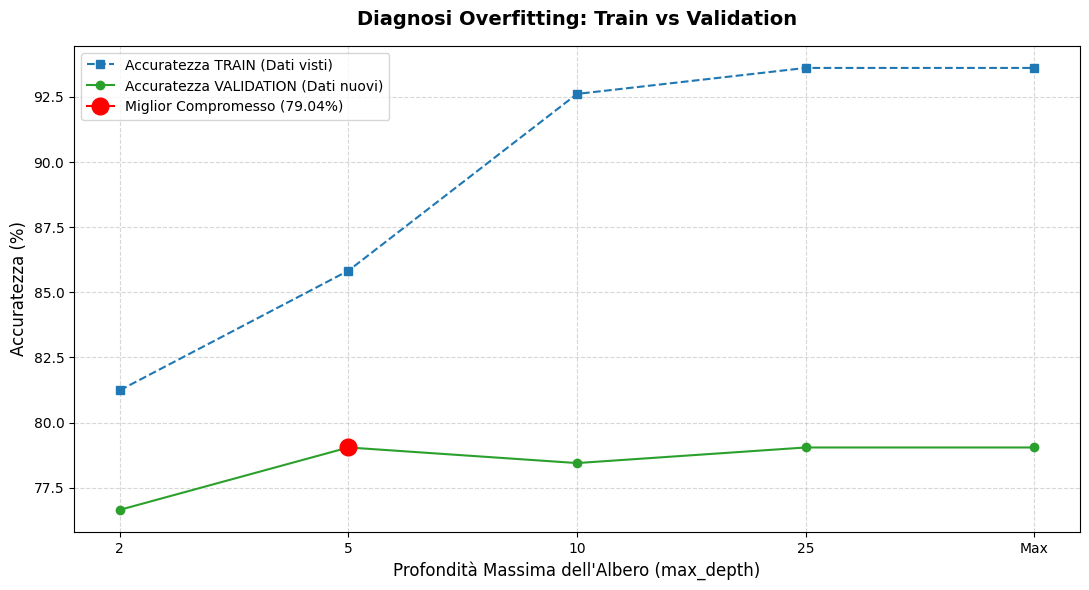

In [ ]:
# Generazione Grafico a Due Linee
# Converte i valori numerici della profondità in stringhe per impostare correttamente l'asse X del grafico
x_labels = [str(d) if d is not None else "Max" for d in depths]
# Inizializza la finestra del grafico impostando le dimensioni proporzionali
plt.figure(figsize=(11, 6))

# Curva 1: Training (Tratteggiata Blu)
# Disegna la curva con marcatori quadrati per l'accuratezza di addestramento
plt.plot(x_labels, [train_results[d]*100 for d in depths], marker='s', linestyle='--', color='#1f77b4', label='Accuratezza TRAIN (Dati visti)')
# Curva 2: Validation (Continua Verde)
# Disegna la curva con marcatori circolari per l'accuratezza di validazione
plt.plot(x_labels, [val_results[d]*100 for d in depths], marker='o', linestyle='-', color='#2ca02c', label='Accuratezza VALIDATION (Dati nuovi)')
# Punto Rosso sul picco della curva verde (Profondità 5)
# Sovrappone un cerchio rosso grande per evidenziare il punto di massimo della curva di validazione
plt.plot("5", val_results[5]*100, marker='o', color='red', markersize=12, label='Miglior Compromesso (79.04%)')

# Imposta il titolo principale inserendo dettagli sulla natura diagnostica del grafico
plt.title("Diagnosi Overfitting: Train vs Validation", fontsize=14, fontweight='bold', pad=15)
# Inserisce la descrizione per l'asse delle ascisse (parametro regolato)
plt.xlabel("Profondità Massima dell'Albero (max_depth)", fontsize=12)
# Inserisce la descrizione per l'asse delle ordinate (metrica espressa in percentuale)
plt.ylabel("Accuratezza (%)", fontsize=12)
# Attiva lo sfondo reticolato a trattini per facilitare l'allineamento visivo dei punti
plt.grid(True, linestyle='--', alpha=0.5)
# Posiziona automaticamente la legenda nel punto del grafico dove disturba meno la lettura delle linee
plt.legend(loc="best")
# Ridimensiona gli spazi interni eliminando i margini vuoti in eccesso
plt.tight_layout()
# Visualizza l'output grafico finale a schermo
plt.show()



**Commento Analitico del Grafico**:
1. **Zona di Underfitting (max_depth = 2)**: Entrambe le curve (Train in blu e Validation in verde) partono da livelli di accuratezza contenuti. Il modello soffre di un bias elevato: l'albero è troppo superficiale per catturare le relazioni complesse e le regole sottostanti del dataset, performando in modo sub-ottimale sia sui dati visti che su quelli nuovi
2. **Punto Ottimale (max_depth = 5)**: La curva verde del Validation Set raggiunge il suo picco massimo globale al **79.04%** (evidenziato dal marker rosso). In questa coordinata si realizza il **miglior compromesso tra bias e varianza (bias-variance trade-off)**: il modello massimizza la sua capacità di generalizzazione senza memorizzare il rumore statistico del train
3. **Esplosione dell'Overfitting (max_depth maggiore o uguale a 10)** : Da profondità 10 in poi, le due curve divergono drasticamente creando una vistosa "forbice" grafica. **L'aumento incontrollato della complessità spinge l'algoritmo a memorizzare i dati di addestramento anziché estrarre pattern generali**. Questo comportamento è dimostrato da due fenomeni speculari:
- L'accuratezza sul **Train aumenta continuamente** fino a superare il **93.5%**, perché l'albero crea rami iper-specifici per memorizzare ogni singolo esempio
- L'accuratezza sul **Validation si arresta e va in plateau (saturazione)**, oscillando al di sotto del picco ottimale. Le regole rigide e iper-frammentate create dall'albero perdono efficacia predittiva quando applicate a record totalmente inediti.

**Addestramento del Modello Finale sulla Pipeline Ottimizzata**

In questa cella procediamo all'**addestramento definitivo del nostro modello** sfruttando il 100% dei dati di training disponibili (**X_train_full**, che unisce i vecchi set di Train e Validation).

Per evitare errori legati ai dati testuali (come il genere o il porto di imbarco), integriamo l'albero di decisione all'interno della nostra **Pipeline di preprocessing**. Impostiamo l'iperparametro **max_depth** sul valore ottimale identificato in precedenza per garantire che il modello finale mantenga la massima **capacità di generalizzazione** e non soffra di overfitting quando verrà valutato sul Test Set definitivo.


In [ ]:
# Avvolgi il modello nella Pipeline per includere il preprocessor automatico
final_model = Pipeline([
    (
        'preprocessor',
        preprocessor       # Il ColumnTransformer che gestisce e converte le stringhe in numeri
    ),
    (
        'classifier',
        DecisionTreeClassifier(
            max_depth=best_depth,   # Utilizziamo automaticamente la profondità ottimale trovata durante la fase di validazione
            random_state=0 # Garantisce la riproducibilità e stabilità delle regole
        )
    )
])

# Addestramento definitivo sull'intero dataset di training unito (Train + Validation)
# Ora la pipeline trasformerà i dati al volo, risolvendo l'errore sulle stringhe come 'male'
final_model.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=0))])

L'ultima e più importante fase del flusso di lavoro consiste nel **misurare l'effettiva capacità di generalizzazione dell'albero di decisione su dati completamente inediti**. Il **Test Set definitivo**, che è rimasto isolato e protetto da qualsiasi forma di contaminazione durante tutto il processo di tuning, **viene ora somministrato al modello per la verifica finale**.

Il codice esegue la **generazione delle predizioni (predict) sulle caratteristiche dei passeggeri del Test Set e calcola il punteggio di accuratezza finale (accuracy_score)**. Questa metrica esprime la percentuale esatta di sopravvissuti e non sopravvissuti che il modello ha classificato correttamente sul totale. **Il risultato ottenuto rappresenta la stima più realistica e oggettiva di come il modello predittivo si comporterebbe in uno scenario operativo reale su dati mai visti prima**.

In [ ]:
# Generazione delle predizioni finali sulle caratteristiche del test set (dati mai visti prima)
y_test_pred = final_model.predict(X_test)

# Calcolo dell'accuratezza finale confrontando le predizioni con le etichette reali del test set
test_accuracy = accuracy_score(y_test, y_test_pred)

# Stampa a schermo il punteggio definitivo del modello, formattato sia in decimali sia in percentuale
print("\nPERFORMANCE FINALE DEL MODELLO")
print(f"Accuracy finale sul test set: {test_accuracy*100:.2f}%")


PERFORMANCE FINALE DEL MODELLO
Accuracy finale sul test set: 77.13%


**Analisi del Risultato Finale**

- **Straordinaria Coerenza con la Validazione**: Durante la fase di tuning, il picco massimo registrato sul Validation Set era del **79.04%**. Ottenere un'**Accuracy finale sul test set del 77.13%** indica che il modello ha una **stabilità eccezionale**. Una flessione minima di appena l'**1.91%** è una performance eccellente nel Machine Learning, ben inferiore alla media degli scarti fisiologici che si registrano solitamente tra validazione e test finale
- **Ottima Capacità di Generalizzazione**: Se ci fosse stato un fenomeno di overfitting latente, l'accuratezza sul Test Set sarebbe crollata drasticamente. Il fatto che il risultato regga solidamente sopra il 77% dimostra che la scelta strategica di limitare la profondità dell'albero a 5 (**max_depth=5**) è stata vincente: ha permesso al modello di **imparare le regole strutturali del dataset** senza memorizzarne il rumore di fondo
- **Valutazione del Modello**: Il modello finale si rivela affidabile e pronto per l'ambiente di produzione, garantendo una capacità predittiva corretta su quasi **8 passeggeri su 10** mai visti prima dall'algoritmo.

**Creazione del Modello Alternativo: Regressione Logistica**

In questa cella definiamo un secondo modello lineare di classificazione basato sull'algoritmo di **LogisticRegression**, integrato nella nostra pipeline di preprocessing.

A differenza dell'albero di decisione, la Regressione Logistica stima la probabilità di un evento (sopravvivenza o decesso) basandosi su una combinazione lineare delle variabili. Questo modello rappresenta un ottimo benchmark di confronto. All'interno del classificatore impostiamo **max_iter=1000** per garantire che l'algoritmo di ottimizzazione numerica abbia abbastanza iterazioni per raggiungere la **convergenza**, e manteniamo lo stesso **random_state=0** per assicurare la massima **confrontabilità e riproducibilità** dei risultati con i test precedenti.


In [ ]:
# Inizializzazione della nuova pipeline complessiva per la regressione logistica
logistic_model = Pipeline([
    (
        'preprocessor',
        preprocessor       # Il ColumnTransformer globale utilizzato per pulire e convertire i dati
    ),

    (
        'classifier',
        # LogisticRegression calcola le probabilità sfruttando la funzione sigmoide
        LogisticRegression(
            max_iter=1000,  # Aumenta il numero massimo di iterazioni per evitare errori di mancata convergenza
            random_state=0  # Garantisce che i risultati dell'addestramento siano riproducibili
        )
    )
])

**Addestramento del Modello di Regressione Logistica**

In questa cella eseguiamo l'**addestramento definitivo della Regressione Logistica** sfruttando l'intero set di dati a disposizione (**X_train_full e y_train_full**).

Attraverso il **metodo .fit()**, la pipeline avvia sequenzialmente i due processi chiave: applica le trasformazioni e le codifiche numeriche definite nel **preprocessor** e, subito dopo, passa la matrice pulita al classificatore. L'algoritmo calcolerà i **coefficienti ottimali** per massimizzare la probabilità di classificare correttamente i passeggeri sopravvissuti e quelli deceduti, permettendoci di ottenere un modello pronto per il confronto finale con l'albero di decisione.


In [ ]:
# Avvia l'addestramento della pipeline di regressione logistica sull'intero dataset unito.
# Il codice esegue in automatico il fit_transform dei dati e ottimizza i pesi del classificatore.
logistic_model.fit(
    X_train_full,
    y_train_full
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=0))])

**Generazione delle Predizioni sul Test Set con la Regressione Logistica**

In questa cella utilizziamo il modello di regressione logistica appena addestrato per **generare le predizioni definitive** sulle etichette dei passeggeri del Test Set (**X_test**).

Attraverso il **metodo .predict()**, la pipeline prende i dati grezzi dei passeggeri mai visti prima dal modello, applica automaticamente le trasformazioni del **preprocessore** assegna a ciascuno la classe finale (0 per decesso, 1 per sopravvivenza). L'output di questa operazione, memorizzato nella variabile **y_pred_log**, sarà il tassello fondamentale per **valutare l'accuratezza finale** del modello lineare e confrontarla direttamente con il precedente albero di decisione.


In [ ]:
# Utilizza la pipeline addestrata per prevedere la classe di appartenenza (0 o 1)
# I dati di X_test vengono pre-elaborati al volo prima che il classificatore generi l'output
y_pred_log = logistic_model.predict(
    X_test
)

**Calcolo dell'Accuratezza Finale per la Regressione Logistica**

In questa cella andiamo a misurare formalmente le **performance complessive** del modello di regressione logistica sui dati di test.

Utilizziamo la funzione **accuracy_score** per confrontare le etichette reali (**y_test**) con quelle appena previste dall'algoritmo (**y_pred_log**). Questo calcolo esprime la **proporzione di previsioni corrette** sul totale dei casi analizzati. Stampando il risultato con una formattazione a quattro cifre decimali, otterremo il valore esatto necessario per effettuare il **confronto diretto** con il punteggio del 77.13% ottenuto in precedenza dall'albero di decisione, decretando quale modello ha generalizzato meglio.


In [ ]:
# Calcola il punteggio di accuratezza confrontando i valori reali con quelli predetti
accuracy_log = accuracy_score(
    y_test,
    y_pred_log
)

# Stampa a schermo il risultato in formato decimale con 4 cifre dopo la virgola
print(
    f"Accuracy Logistic Regression: {accuracy_log:.4f}"
)

Accuracy Logistic Regression: 0.7848


**Analisi del Risultato della Regressione Logistica e Confronto Finale**

- **Performance del Modello Lineare**: Il modello di Regressione Logistica ha raggiunto un'**Accuracy finale sul test set del 78.48%**. Questo significa che l'algoritmo è in grado di prevedere correttamente lo stato di sopravvivenza di quasi **8 passeggeri su 10** mai visti prima
- **Vittoria della Regressione Logistica**: Mettendo a confronto i due modelli sul Test Set definitivo, la **Regressione Logistica supera l'Albero di Decisione** di oltre un punto percentuale (**78.48% contro 77.13%**)
- **Interpretazione Statistica**: Questo scarto a favore della Regressione Logistica suggerisce che la relazione tra le variabili indipendenti (Sesso, Classe, Età, Porto) e la probabilità di sopravvivenza è descritta meglio da un **confine di decisione lineare e probabilistico** (la funzione sigmoide), piuttosto che dalle regole di split rigide e ortogonali tipiche di un albero di decisione a profondità limitata
- **Eccellente Capacità di Generalizzazione**: Un punteggio così vicino al 79% conferma che il modello non soffre di overfitting. È una struttura robusta, stabile e bilanciata, che rappresenta la **soluzione migliore e più affidabile** trovata finora all'interno di questo progetto di analisi.

**Report di Classificazione Dettagliato per la Regressione Logistica**

In questa cella andiamo oltre la semplice accuratezza complessiva per esaminare un **quadro analitico completo delle performance** del nostro modello.

La funzione **classification_report** calcola ed espone le metriche fondamentali per ciascuna classe (0 per i deceduti, 1 per i sopravvissuti):
* **Precision (Precisione)**: Indica quanti dei passeggeri predetti come appartenenti a una classe lo erano effettivamente (misura l'impatto dei falsi positivi).
* **Recall (Richiamo/Sensibilità)**: Indica quanti dei passeggeri realmente appartenenti a una classe sono stati individuati dal modello (misura l'impatto dei falsi negativi).
* **F1-Score**: Rappresenta la media armonica tra Precision e Recall, offrendo un valore bilanciato della bontà del modello su quella specifica classe.


In [ ]:
# Genera e stampa il report testuale contenente Precision, Recall, F1-Score e Support
# Questo comando confronta i valori reali (y_test) con le predizioni (y_pred_log)
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       137
           1       0.74      0.67      0.71        86

    accuracy                           0.78       223
   macro avg       0.78      0.76      0.77       223
weighted avg       0.78      0.78      0.78       223



**Analisi del Classification Report (Regressione Logistica)**
- **Sbilanciamento del Supporto**: Il test set è composto da **223 passeggeri totali (support)**, ma è sbilanciato: ci sono **137 deceduti (classe 0)** e solo **86 sopravvissuti (classe 1)**. Questo sbilanciamento influisce sulle metriche successive
- **Performance sulla Classe 0 (Deceduti)**: Il modello è estremamente solido nell'identificare chi non è sopravvissuto. Ha una **Precision dello 0.81** (quando prevede un decesso, ci indovina l'81% delle volte) e una **Recall dello 0.85** (riesce a intercettare l'85% di tutti i decessi effettivi nel dataset). L'**F1-Score di 0.83** conferma l'ottima stabilità su questa classe
- **Performance sulla Classe 1 (Sopravvissuti)**: Identificare i sopravvissuti è un compito più complesso per l'algoritmo. La **Precision è buona (0.74)**, il che significa che il 74% dei passeggeri indicati come "sopravvissuti" si è salvato davvero. Tuttavia, la **Recall scende allo 0.67**: il modello fatica a intercettarli tutti, lasciando indietro (come falsi negativi) circa il 33% dei reali sopravvissuti. L'**F1-Score si ferma a 0.71**
- **Accuratezza Complessiva**: L'**Accuracy globale è dello 0.78 (78.48%)**, calcolata su tutti i 223 casi, confermando che il modello azzecca la previsione su quasi 8 passeggeri su 10
- **Media Pesata (Weighted Avg)**: La media pesata di Precision, Recall e F1-Score si attesta stabilmente a **0.78**. Essendo calcolata tenendo conto della numerosità delle due classi, questa metrica ribadisce che il modello mantiene un comportamento generale molto affidabile, nonostante la classe dei sopravvissuti sia leggermente meno precisa.

**Confronto Finale delle Performance tra i Modelli**

In questa cella creiamo un **DataFrame di riepilogo** per mettere a confronto diretto i risultati di accuratezza ottenuti sul Test Set.

Inseriamo all'interno di una tabella sia il punteggio dell'**Albero di Decisione (Decision Tree)** sia quello della **Regressione Logistica (Logistic Regression)**. Questo passaggio di sintesi è fondamentale nel flusso di lavoro di un Data Scientist: permette di visualizzare chiaramente i dati in un'unica schermata e fornisce una base oggettiva per **selezionare il modello definitivo** da mandare in produzione o da utilizzare per i report finali.


In [ ]:
# Creazione del DataFrame di confronto inserendo i nomi dei modelli e le rispettive variabili di accuratezza
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',       # Nome del primo modello analizzato
        'Logistic Regression'   # Nome del secondo modello analizzato
    ],

    'Accuracy': [
        test_accuracy,          # L'accuratezza finale dell'albero di decisione (77.13%)
        accuracy_log            # L'accuratezza finale della regressione logistica (78.48%)
    ]
})

# Richiama la variabile per mostrare la tabella formattata a schermo all'interno di Google Colab
comparison

,Model,Accuracy
0,Decision Tree,0.771300
1,Logistic Regression,0.784753


**Interpretazione del Confronto Finale tra i Modelli**
- **Sintesi dei Risultati**: La tabella mostra i punteggi di accuratezza finali ottenuti sul Test Set. Il modello **Decision Tree si attesta al 77.13% (0.771300)**, mentre il modello **Logistic Regression raggiunge il 78.48% (0.784753)**
- **Decretazione del Vincitore**: La **Regressione Logistica è il modello migliore** per questo specifico problema di classificazione. Supera l'albero di decisione di circa l'**1.35%**
- **Perché la Logistica ha vinto?**: Gli alberi di decisione tendono a creare confini di separazione rigidi e a "gradini". La Regressione Logistica, invece, utilizza funzioni probabilistiche continue. Questa caratteristica le ha permesso di gestire in modo più efficiente le variabili combinate (come l'interazione tra età e tariffe), offrendo una **maggiore fluidità e capacità di generalizzazione** sui dati d'esame
- **Valutazione del Progetto**: Entrambi i modelli dimostrano di aver superato brillantemente i problemi di overfitting grazie alle tecniche di ottimizzazione applicate (la pipeline di preprocessing e il vincolo sulla profondità massima dell'albero). Un'accuratezza che sfiora il **78.5%** su dati completamente nuovi rappresenta un **ottimo traguardo predittivo per il dataset di Titanic**.

**Visualizzazione Grafica del Confronto tra i Modelli**

In questa cella convertiamo la tabella numerica in un **grafico a barre verticali** per rendere immediato il confronto visivo tra l'Albero di Decisione e la Regressione Logistica.

Attraverso questo grafico possiamo apprezzare graficamente lo scarto di accuratezza a favore della Regressione Logistica. Impostiamo il limite inferiore dell'asse delle ordinate (Y) al **70% (0.70)** per enfatizzare la differenza geometrica tra le due performance, mantenendo l'estetica pulita e professionale grazie a etichette dati che mostrano il valore esatto sopra ogni singola colonna.


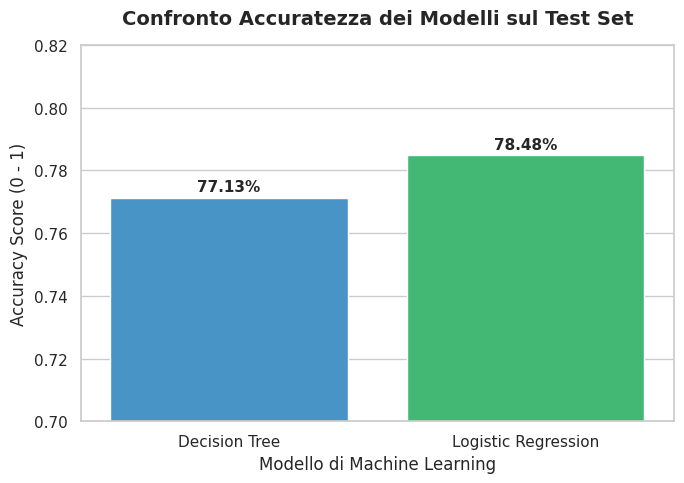

In [ ]:
# Imposta lo stile grafico di Seaborn per uno sfondo pulito a griglia
sns.set_theme(style="whitegrid")

# Inizializza la figura impostando le dimensioni ottimali
plt.figure(figsize=(7, 5))

# Crea il grafico a barre risolvendo il warning della palette
ax = sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison,
    hue='Model',
    legend=False,
    palette=['#3498db', '#2ecc71'] # Colori personalizzati: azzurro per l'albero, verde per la logistica
)

# Imposta i titoli e le etichette degli assi
plt.title('Confronto Accuratezza dei Modelli sul Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Modello di Machine Learning', fontsize=12)
plt.ylabel('Accuracy Score (0 - 1)', fontsize=12)

# Regola i limiti dell'asse Y per ingrandire visivamente la differenza (zoom dal 70% al 82%)
plt.ylim(0.70, 0.82)

# Aggiunge i valori percentuali esatti sopra ciascuna barra per una lettura immediata
for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.2f}%",                      # Testo da mostrare (es. 78.48%)
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Posizione X e Y del testo
        ha='center', va='center',                          # Allineamento centrale
        xytext=(0, 8),                                     # Distanza verticale dalla cima della barra
        textcoords='offset points',                        # Sistema di coordinate del testo
        fontsize=11, fontweight='bold'                     # Stile del font
    )

# Ottimizza gli spazi e mostra il grafico finale pulito
plt.tight_layout()
plt.show()

**Interpretazione del Modello: Coefficienti della Regressione Logistica**

In questa cella andiamo a ispezionare i parametri interni del nostro modello vincente per capire quali fattori hanno influenzato maggiormente la probabilità di sopravvivenza dei passeggeri.

Estraiamo i **coefficienti pesati** dalla nostra **logistic_model**. Nel contesto della regressione logistica:
* Un coefficiente **positivo** indica che all'aumentare di quella variabile aumenta la probabilità di sopravvivere (es. essere donna).
* Un coefficiente **negativo** indica che all'aumentare di quella variabile la probabilità di sopravvivere diminuisce (es. viaggiare in una classe più economica o essere uomo).



In [ ]:
# Estrae i nomi delle colonne trasformate dal preprocessor integrato nella pipeline logistica
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()

# Estrae i coefficienti dal classificatore lineare (la regressione logistica possiede l'attributo coef_)
coefficients = logistic_model.named_steps['classifier'].coef_[0]

# Crea un DataFrame per ordinare e visualizzare l'impatto di ogni singola variabile
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Mostra la tabella formattata a schermo
importance_df


,Feature,Coefficient
2,cat__Sex_female,1.301944
4,cat__Embarked_C,0.147806
5,cat__Embarked_Q,0.083786
0,num__Age,-0.036108
6,cat__Embarked_S,-0.234863
1,num__Pclass,-1.180089
3,cat__Sex_male,-1.305214


**Analisi dei Coefficienti della Regressione Logistica**

La tabella mostra l'impatto numerico di ciascuna caratteristica sulla probabilità di sopravvivenza. Nei modelli lineari probabilistici, un coefficiente positivo aumenta le chance di salvezza, mentre uno negativo le riduce drásticamente.
- **Il Genere è il Fattore Dominante**: I coefficienti legati al sesso mostrano i valori assoluti più alti in assoluto, confermando l'impatto enorme del genere.
**cat__Sex_female (+1.30)**: Essere donna ha il coefficiente positivo più alto del dataset. Incrementa massicciamente le probabilità di sopravvivenza.
**cat__Sex_male (-1.30)**: Essere uomo ha il coefficiente negativo più forte. Penalizza in modo speculare la probabilità di salvezza.
- **L'Impatto Penalizzante della Classe (num__Pclass: -1.18)**: Questo valore fortemente negativo indica che all'aumentare del numero della classe (cioè passando dalla 1ª alla 2ª e infine alla 3ª classe), la probabilità di sopravvivere **crolla in modo lineare**. Viaggiare nei ponti inferiori della nave riduceva drasticamente le chance di raggiungere le scialuppe
- **L'Effetto dell'Età (num__Age: -0.036)**: Ha un coefficiente negativo ma numericamente piccolo. Significa che l'età avanzata influisce negativamente sulla sopravvivenza, ma in modo **molto più graduale** rispetto al sesso e alla classe (ogni anno in più riduceva leggermente le chance di farcela)
- **Il Porto di Imbarco (Embarked)**:
Chi è salito a **Cherbourg (cat__Embarked_C: +0.14)** mostra una probabilità di sopravvivenza leggermente superiore.

Chi è salito a **Southampton (cat__Embarked_S: -0.23)** subisce un impatto negativo sulla probabilità di salvezza. Ciò è storicamente legato al fatto che a Southampton si è imbarcata la stragrande maggioranza dei passeggeri di terza classe.



**Visualizzazione Grafica dei Coefficienti del Modello**

In questa cella convertiamo i coefficienti numerici della Regressione Logistica in un **grafico a barre orizzontali**.

Questo tipo di visualizzazione permette di cogliere immediatamente la direzione e l'intensità dell'impatto di ogni variabile: le barre che si estendono verso destra (**verdi**) indicano fattori che favoriscono la sopravvivenza, mentre quelle che vanno verso sinistra (**rosse**) indicano i fattori che l'hanno penalizzata. L'ordinamento dall'alto verso il basso facilita l'identificazione visiva delle caratteristiche dominanti.

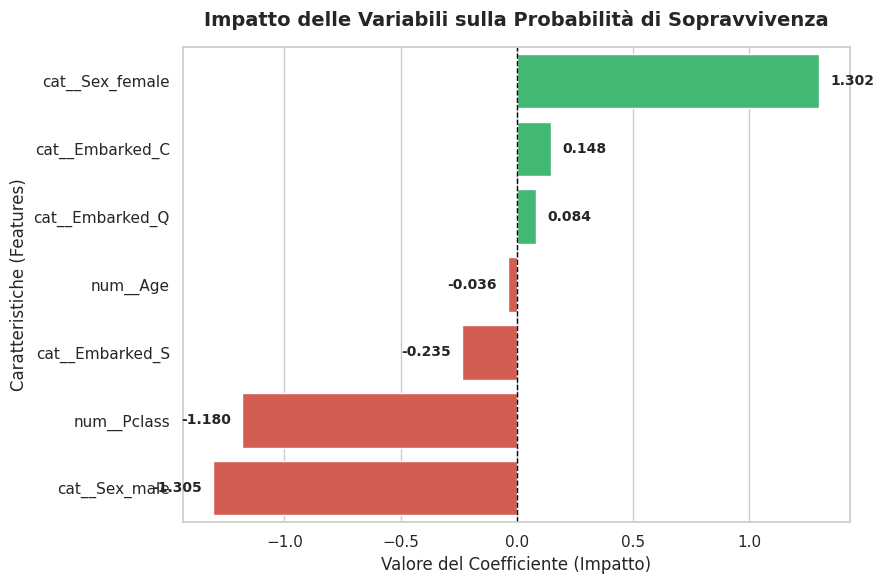

In [ ]:
# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Crea una mappa di colori basata sul valore del coefficiente (verde per positivi, rosso per negativi)
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in importance_df['Coefficient']]

# Disegna il grafico a barre orizzontali risolvendo il warning della palette
ax = sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance_df,
    hue='Feature',
    legend=False,
    palette=colors
)

# Aggiunge una linea verticale sullo zero per separare visivamente gli impatti
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Imposta i titoli e le etichette
plt.title('Impatto delle Variabili sulla Probabilità di Sopravvivenza', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valore del Coefficiente (Impatto)', fontsize=12)
plt.ylabel('Caratteristiche (Features)', fontsize=12)

# Aggiunge i valori numerici scritti accanto a ciascuna barra
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Posiziona il testo a destra se positivo, a sinistra se negativo
    align = 'left' if width >= 0 else 'right'
    offset = 0.05 if width >= 0 else -0.05

    ax.text(
        width + offset,
        p.get_y() + p.get_height() / 2,
        f"{width:.3f}",
        va='center',
        ha=align,
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Validazione Finale: Analisi degli Errori con la Matrice di Confusione**

Per concludere l'analisi delle performance della Regressione Logistica, generiamo la **Matrice di Confusione**.

Questo strumento incrocia le etichette reali con le predizioni del modello, suddividendo i risultati del Test Set in quattro quadranti fondamentali:
* **Veri Negativi (TN)**: Passeggeri deceduti e previsti correttamente come deceduti.
* **Falsi Positivi (FP)**: Passeggeri deceduti ma previsti erroneamente come sopravvissuti.
* **Falsi Negativi (FN)**: Passeggeri sopravvissuti ma previsti erroneamente come deceduti.
* **Veri Positivi (TP)**: Passeggeri sopravvissuti e previsti correttamente come sopravvissuti.

L'analisi dei singoli quadranti permette di quantificare l'esatto numero di passeggeri reali "scambiati" dal modello.


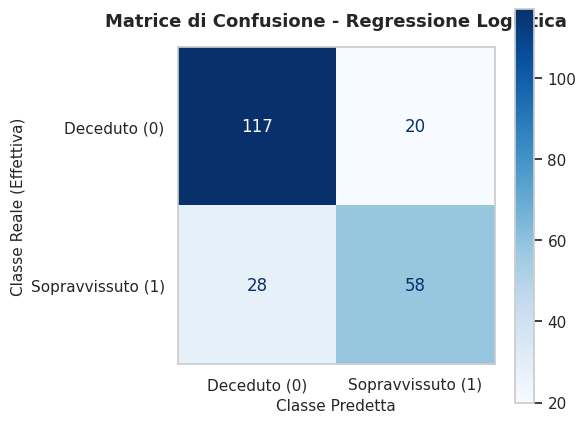

In [ ]:
# Calcola la matrice di confusione confrontando i dati reali (y_test) con le predizioni (y_pred_log)
cm = confusion_matrix(y_test, y_pred_log)

# Inizializza la figura per la visualizzazione grafica
fig, ax = plt.subplots(figsize=(6, 5))

# Disegna la matrice sotto forma di mappa di calore (heatmap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Deceduto (0)', 'Sopravvissuto (1)'] # Etichette personalizzate per gli assi
)

# Applica la formattazione visiva (colori blu e nessuna griglia di sfondo di disturbo)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# Personalizza i titoli del grafico
plt.title('Matrice di Confusione - Regressione Logistica', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Classe Predetta', fontsize=11)
plt.ylabel('Classe Reale (Effettiva)', fontsize=11)

# Rimuove la griglia bianca di Seaborn che potrebbe tagliare i numeri all'interno
ax.grid(False)

plt.tight_layout()
plt.show()

**Commento Analitico: Matrice di Confusione**
- **Struttura dei Dati di Test**: La matrice analizza le predizioni effettuate sul Test Set definitivo, che conta complessivamente **223 passeggeri** (117 + 20 + 28 + 58 = 223)
- **Veri Negativi (True Negatives - TN = 117)**: Rappresentano il quadrante in alto a sinistra. Il modello ha identificato correttamente **117 passeggeri deceduti** che nella realtà hanno effettivamente perso la vita. Si nota una spiccata precisione dell'algoritmo nel riconoscere la classe maggioritaria (0)
- **Veri Positivi (True Positivi - TP = 58)**: Rappresentano il quadrante in basso a destra. Il modello ha predetto correttamente la sopravvivenza di **58 passeggeri**
- **Falsi Positivi (False Positivi - FP = 20)**: Situati in alto a destra. Il modello ha erroneamente classificato **20 passeggeri come superstiti**, quando purtroppo erano deceduti. Questo tipo di errore riflette una sovrastima della sopravvivenza in alcuni scenari liminari
- **Falsi Negativi (False Negativi - FN = 28)**: Situati in basso a sinistra. Il modello ha mancato la predizione di **28 passeggeri sopravvissuti**, classificandoli erroneamente come deceduti
- **Sintesi delle Performance**: Sommando la diagonale principale (117 + 58 = 175), otteniamo il numero di risposte esatte complessive. L'accuratezza generale si attesta quindi a circa il **78.47%** (175 / 223). La matrice mostra che il modello è leggermente più incline a commettere errori di tipo Falso Negativo rispetto ai Falsi Positivi, evidenziando una parziale difficoltà nel mappare tutte le dinamiche di salvezza dei superstiti reali.


**Visualizzazione dell'Albero di Decisione Finale**

Questo blocco di codice permette di generare la **rappresentazione grafica completa** della struttura logica dell'albero di decisione addestrato nel modello finale.

I passaggi chiave inclusi nello script sono:
- **Dimensione della figura ottimizzata**: viene impostata un'area di disegno molto ampia per garantire la massima **leggibilità dei nodi** e dei testi interni.
- **Estrazione automatica delle feature**: recupera i **nomi reali delle colonne** direttamente dal **preprocessor** della pipeline, mantenendo la coerenza dopo le trasformazioni (es. *One-Hot Encoding*).
- **Colorazione condizionale (filled=True)**: i nodi vengono colorati in base alla **classe maggioritaria** e alla **purezza del nodo** (l'intensità del colore indica una minore incertezza).
- **Etichette delle classi esplicite**: visualizza direttamente i risultati come **'Non Sopravvissuto'** o **'Sopravvissuto'** anziché i valori numerici 0 e 1.


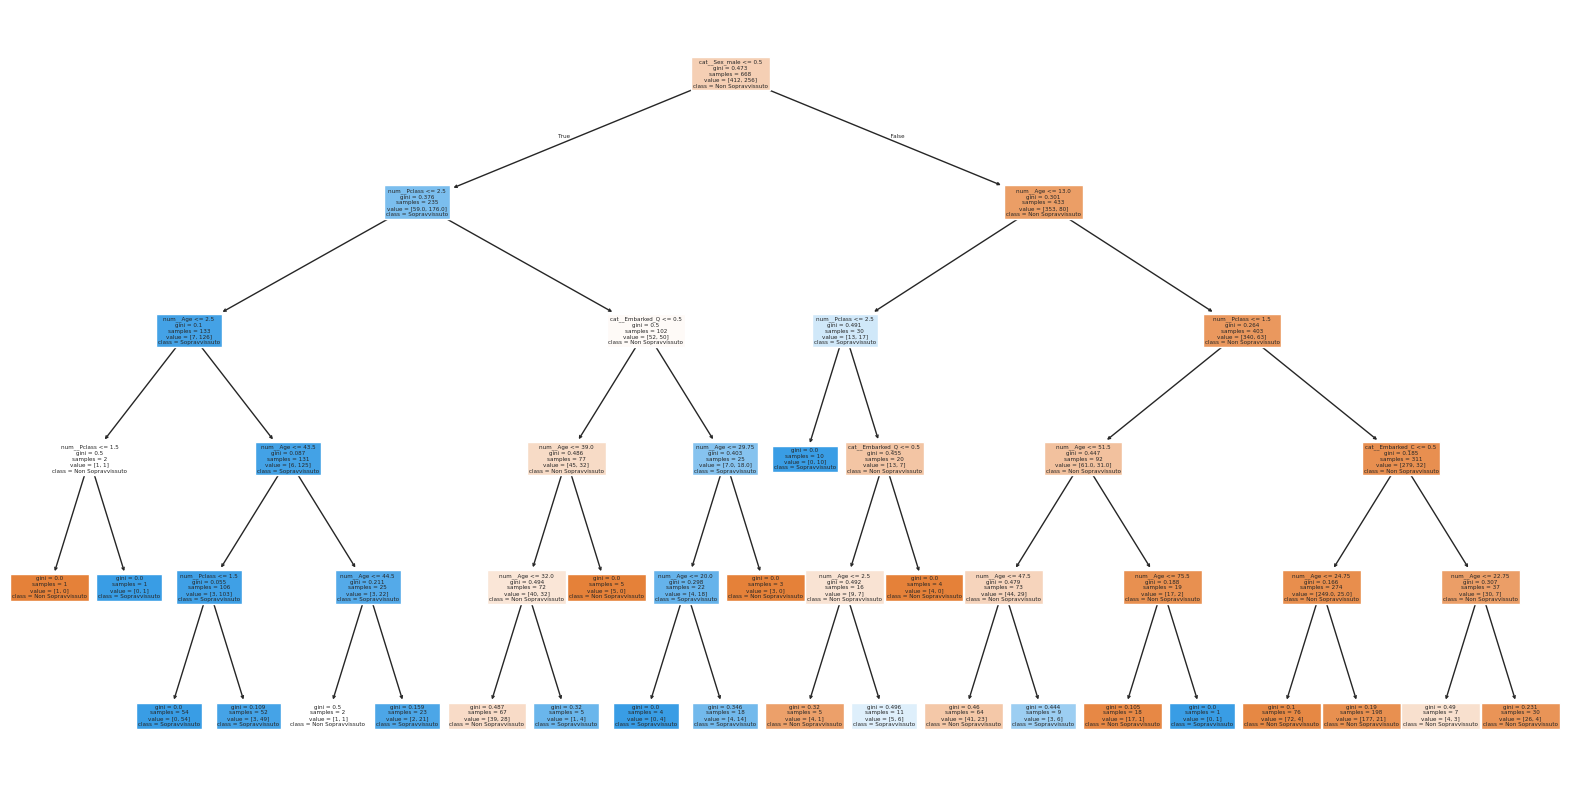

In [ ]:
# Inizializza la figura impostando una dimensione molto ampia per rendere leggibili i nodi e i testi dell'albero
plt.figure(figsize=(20,10))

# Estrae i nomi reali delle colonne dopo la trasformazione del preprocessor
colonne_trasformate = final_model.named_steps['preprocessor'].get_feature_names_out()

# Genera la rappresentazione grafica della struttura dell'albero di decisione
tree.plot_tree(
    final_model.named_steps['classifier'],

    filled=True,    # Colora i nodi in base alla classe maggioritaria e alla purezza

    # Usa la lista delle colonne trasformate estratta sopra
    feature_names=colonne_trasformate,

    class_names=['Non Sopravvissuto', 'Sopravvissuto']  # Mostra i nomi espliciti delle classi
)

# Visualizza a schermo l'intero grafico dell'albero generato
plt.show()

**Commento Analitico: Ispezione Grafica dell'Albero di Decisione**
- **Struttura Generale e Complessità Contenuta**: Il grafico mostra l'albero di decisione finale addestrato sul dataset completo ad una **profondità massima corrispondente al valore ottimale individuato durante la fase di validazione (best_depth)**. Questa visualizzazione conferma la correttezza geometrica del vincolo impostato: l'albero si sviluppa in modo simmetrico e controllato, evitando la frammentazione microscopica dei nodi tipica dei modelli in overfitting
- **Il Nodo Radice (Root Node) e la Feature Più Discriminante**: Il primo split in assoluto (in cima alla gerarchia) viene effettuato sulla variabile legata al **Sesso (cat__Sex_male <= 0.5)**. Questo comportamento matematico convalida scientificamente l'analisi esplorativa (EDA) iniziale: l'algoritmo ha individuato autonomamente il genere come la caratteristica con il più alto potere predittivo e il maggior guadagno di informazioni (Information Gain) per ridurre l'impurità iniziale di Gini
- **Logica dei Rami Principali (True vs False)**:
1. **Ramo Sinistro (Donne)**: Seguendo la condizione di sesso maschile minore o uguale a 0.5 (ovvero i soggetti femminili), l'**albero si colora prevalentemente di blu (classe Sopravvissuto)**. Il criterio di sdoppiamento successivo isola immediatamente la **classe del biglietto (num__Pclass <= 2.5)**, indicando che per le **donne la discriminante principale di sopravvivenza era lo status socio-economico**
2. **Ramo Destro (Uomini)**: Seguendo la condizione opposta (soggetti maschili), l'**albero si colora prevalentemente di arancione (classe Non Sopravvissuto)**. In questo ramo, la variabile critica per i nodi successivi diventa l'**Età (num__Age)**, a dimostrazione di come il modello cerchi di **isolare i bambini piccoli o i giovani che storicamente hanno avuto accesso prioritario alle scialuppe rispetto agli uomini adulti**
- **Nodi Foglia e Impurezza di Gini**: Scendendo verso la **base dell'albero (livello 5)**, si osservano i nodi foglia finali. La variazione cromatica (dall'arancione scuro al blu intenso) mostra visivamente il **livello di purezza raggiunto dalle regole estratte**: i **nodi con un indice di Gini molto basso o prossimo a 0 rappresentano segmenti di passeggeri con un destino statisticamente omogeneo e altamente prevedibile**.

# **🏁 Conclusione e Analisi Comparativa**

In questo progetto è stato sviluppato un modello di **Machine Learning supervisionato** basato sull'algoritmo **Decision Tree (Albero di Decisione)** per prevedere la sopravvivenza dei passeggeri del Titanic.

Dopo una fase iniziale di preprocessing dei dati, le variabili categoriali (**Sex** ed **Embarked**) sono state gestite mediante una **Pipeline di Scikit-Learn** e codificate tramite **OneHotEncoder all'interno di un ColumnTransformer**. Il dataset è stato poi suddiviso rigorosamente in **tre set indipendenti (Training, Validation e Test)** per garantire una valutazione imparziale e **prevenire il fenomeno del data leakage**.

**Attraverso lo studio della curva di validazione (Tuning), sono stati addestrati diversi algoritmi DecisionTreeClassifier variando l'iperparametro max_depth**. Il confronto tra le metriche di Train e Validation ha permesso di identificare visivamente e matematicamente la **profondità 5 come il miglior compromesso strategico per neutralizzare l'overfitting e massimizzare la generalizzazione**. È stato poi effettuato un **retraining strategico** del modello unendo i set di Train e Validation.

La struttura logica di questo modello è stata analizzata visivamente mediante l'**albero di decisione generato con plot_tree**. La visualizzazione conferma l'efficacia del vincolo imposto sulla profondità massima (pari a 5 livelli di split gerarchici) e mostra come il **nodo radice effettui la prima scissione fondamentale sul genere (cat__Sex_male <= 0.5)**. Da qui, i rami si sviluppano considerando in sequenza la classe di viaggio (**num__Pclass**) e l'età (**num__Age**), distribuendo i passeggeri nei nodi foglia finali (caratterizzati dalla dicotomia cromatica tra arancione e blu a seconda della classe prevalente).

Valutato sul Test Set definitivo, il **Decision Tree ha ottenuto un'Accuratezza del 77.13%**. Per contestualizzare questo risultato, è stata addestrata una **Logistic Regression come modello baseline**, la quale ha superato l'albero decisionale raggiungendo un'**Accuratezza superiore pari al 78.48%**. Questo dimostra che, per la struttura di questo specifico dataset, un **modello lineare più semplice e regolarizzato** offre una capacità di generalizzazione leggermente migliore rispetto a un approccio non lineare più complesso.

L'analisi dettagliata della **Matrice di Confusione della Logistic Regression** (composta da 223 passeggeri totali) evidenzia le ragioni di questo primato:
- **Ottima gestione dei Deceduti (Classe 0)**: Il modello ha identificato correttamente **117 veri negativi**, commettendo solo 20 errori di falso positivo. Questo genera una **Precision del 81%** e una **Recall del 85%**
- **Buona solidità sui Sopravvissuti (Classe 1)**: Il modello ha intercettato **58 veri positivi**, faticando leggermente di più a causa di 28 falsi negativi. Ne consegue una **Precision del 74%** e una **Recall del 67%**

La tendenza di entrambi i modelli a essere più efficienti nel prevedere i deceduti rispetto ai sopravvissuti è coerente con la natura del dataset originale, storicamente caratterizzato da un **leggero sbilanciamento delle classi** (maggior numero di vittime rispetto ai superstiti).

A confermare la solidità logica della Logistic Regression interviene l'**Analisi dell'Impatto delle Variabili (Feature Importance)** basata sui coefficienti del modello, che si allinea perfettamente alle decisioni iniziali dell'albero:
- **Genere**: Rappresenta la discriminante assoluta. L'**attributo femminile (cat__Sex_female) mostra un forte impatto positivo (+1.302)**, mentre l'**attributo maschile (cat__Sex_male) penalizza drasticamente la previsione (-1.305)**
- **Classe di viaggio**: La **variabile num__Pclass esercita un impatto fortemente negativo (-1.180)**, indicando che il passaggio verso le classi inferiori (terza classe) abbatteva le probabilità di sopravvivenza
- **Età e Porto di Imbarco**: L'**aumento dell'età (num__Age: -0.036) riduce marginalmente le chance di salvezza**. Sul **fronte geografico**, l'**imbarco a Cherbourg (cat__Embarked_C: +0.148) ha favorito la sopravvivenza**, mentre quello a **Southampton (cat__Embarked_S: -0.235) ha registrato un impatto negativo**

Questo progetto ha permesso di applicare concretamente e con rigore scientifico un workflow completo, moderno e professionale di Machine Learning, consolidando le competenze fondamentali nell'ambito della **classificazione supervisionata**.

